# Práctica 5: El sol y las estaciones

In [2]:
!pip install astroquery matplotlib astropy -q

Práctica simulada con stellarium <-> `Astroquery`

Definir el momento en el que inicia el día. ¿Cuando el sol sale completamente por el horizonte? ¿Cuando empieza a salir?

Hora de salida -> Angulo de elevación `EL` -> Hora de oculatación

Hora, fecha y lugar

Revisar guía de la práctica

Calculando posición del Sol para 365 días …


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/sol_medellin_2024.png'

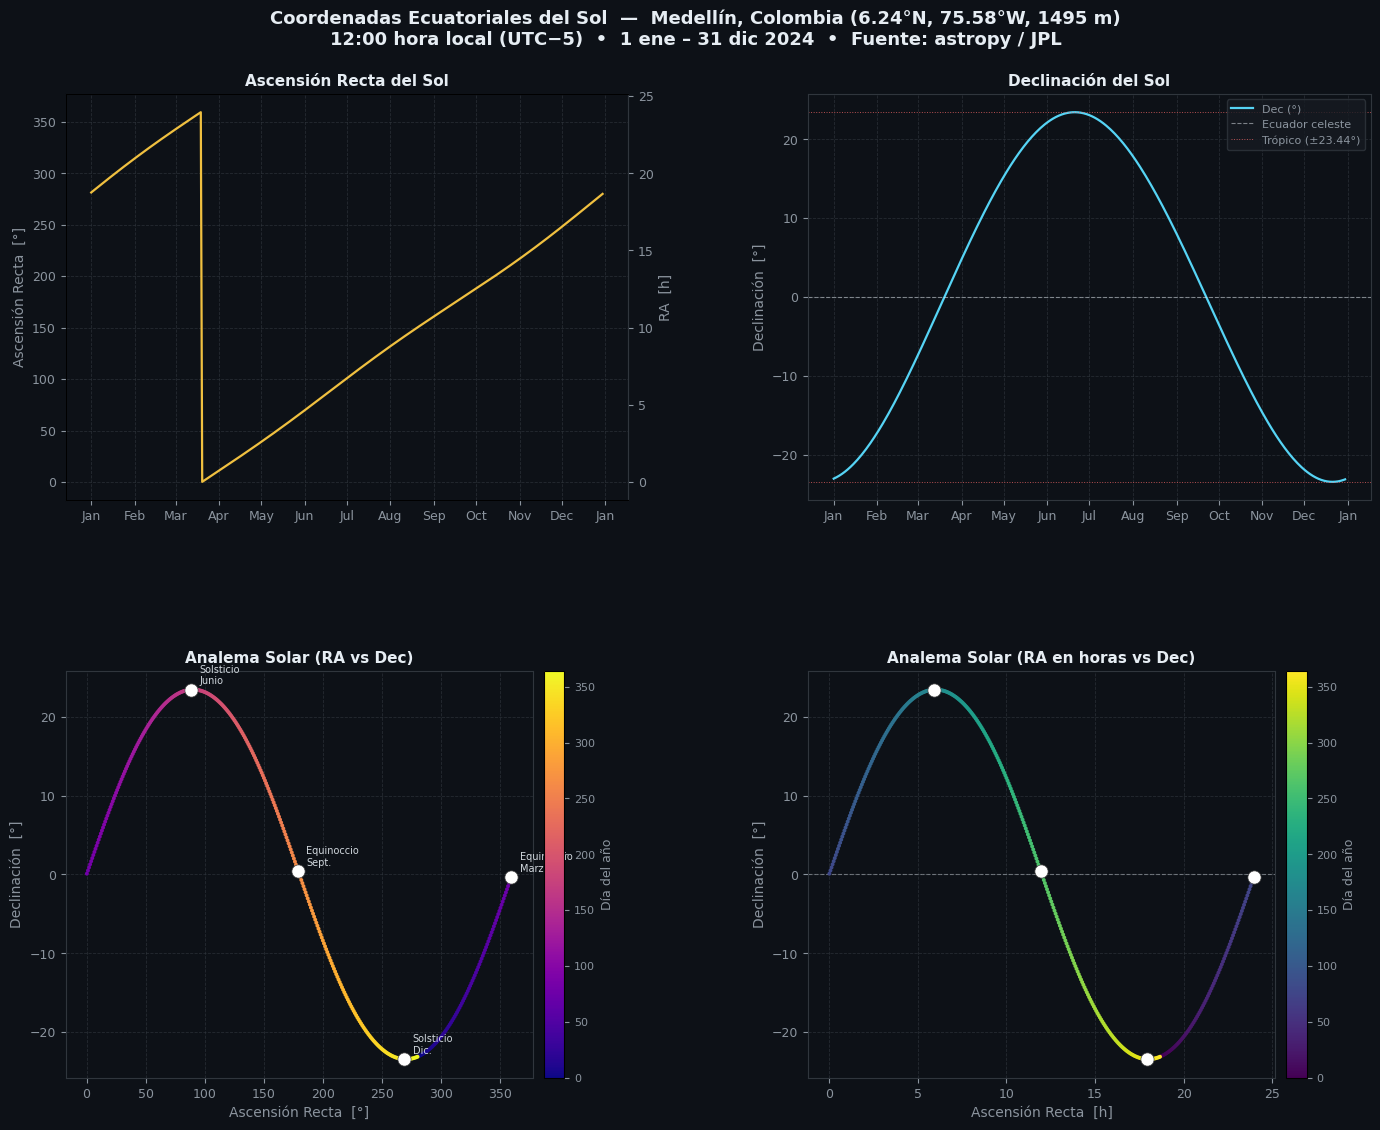

In [5]:
"""
Coordenadas del Sol (RA y Declinación) vistas desde Medellín, Colombia
Cada día durante un año a las 12:00 hora local (UTC-5 → 17:00 UTC)

Medellín, Colombia:
  Latitud  :  6.2442° N
  Longitud : -75.5812° W
  Elevación:  1495 m s.n.m.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from astropy.coordinates import EarthLocation, get_body
from astropy.time import Time
import astropy.units as u
from datetime import datetime, timedelta

# ── Ubicación: Medellín, Colombia ──────────────────────────────────────────────
medellin = EarthLocation(
    lat=6.2442 * u.deg,
    lon=-75.5812 * u.deg,
    height=1495 * u.m
)

# ── Tiempos: cada día del año 2024 a las 12:00 UTC-5 (= 17:00 UTC) ───────────
n_days = 365
t0_utc = Time("2024-01-01 17:00:00", scale="utc")   # 12:00 local → +5 h UTC
times  = t0_utc + np.arange(n_days) * u.day

# ── Obtener coordenadas del Sol con astroquery / astropy ──────────────────────
print("Calculando posición del Sol para 365 días …")
sun = get_body("sun", times, medellin)   # topocéntrico (desde Medellín)

ra_deg  = sun.ra.deg                     # Ascensión Recta  [0, 360) °
dec_deg = sun.dec.deg                    # Declinación      [-23.5, +23.5] °

# Convertir RA de grados a horas para el eje secundario
ra_hours = ra_deg / 15.0

# Fechas para el eje X
dates = [datetime(2024, 1, 1) + timedelta(days=i) for i in range(n_days)]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 12), facecolor="#0d1117")
gs  = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32,
               left=0.08, right=0.95, top=0.90, bottom=0.08)

dark_bg   = "#0d1117"
grid_col  = "#30363d"
gold      = "#f0c040"
cyan      = "#56d4f5"
white     = "#e6edf3"
gray_text = "#8b949e"

text_kw   = dict(color=white, fontfamily="DejaVu Sans")
label_kw  = dict(color=gray_text, fontsize=10)
tick_kw   = dict(color=gray_text, labelsize=9)

def style_ax(ax):
    ax.set_facecolor(dark_bg)
    for sp in ax.spines.values():
        sp.set_color(grid_col)
    ax.tick_params(colors=gray_text, labelsize=9)
    ax.xaxis.label.set_color(gray_text)
    ax.yaxis.label.set_color(gray_text)
    ax.grid(True, color=grid_col, linewidth=0.6, linestyle="--", alpha=0.7)

# ─── 1. RA vs Tiempo ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
ax1.plot(dates, ra_deg, color=gold, lw=1.6, label="RA (°)")
ax1.set_ylabel("Ascensión Recta  [°]", **label_kw)
ax1.set_title("Ascensión Recta del Sol", **text_kw, fontsize=11, fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
# Eje secundario en horas
ax1b = ax1.twinx()
ax1b.set_ylim(np.array(ax1.get_ylim()) / 15.0)
ax1b.set_ylabel("RA  [h]", color=gray_text, fontsize=10)
ax1b.tick_params(colors=gray_text, labelsize=9)
ax1b.spines["right"].set_color(grid_col)

# ─── 2. Declinación vs Tiempo ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
ax2.plot(dates, dec_deg, color=cyan, lw=1.6, label="Dec (°)")
ax2.axhline(0,  color=white, lw=0.8, ls="--", alpha=0.5, label="Ecuador celeste")
ax2.axhline( 23.44, color="#ff6b6b", lw=0.7, ls=":", alpha=0.7, label="Trópico (±23.44°)")
ax2.axhline(-23.44, color="#ff6b6b", lw=0.7, ls=":", alpha=0.7)
ax2.set_ylabel("Declinación  [°]", **label_kw)
ax2.set_title("Declinación del Sol", **text_kw, fontsize=11, fontweight="bold")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.legend(loc="upper right", fontsize=8, facecolor="#161b22",
           edgecolor=grid_col, labelcolor=gray_text)

# ─── 3. Analema (RA vs Dec) ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3)
# Colorear por día del año
sc = ax3.scatter(ra_deg, dec_deg, c=np.arange(n_days),
                 cmap="plasma", s=8, linewidths=0, zorder=3)
# Marcar solsticios y equinoccios
eventos = {
    "Equinoccio\nMarzo":    ("2024-03-20", "▲"),
    "Solsticio\nJunio":     ("2024-06-20", "◆"),
    "Equinoccio\nSept.":    ("2024-09-22", "▼"),
    "Solsticio\nDic.":      ("2024-12-21", "◆"),
}
for nombre, (fecha, marker) in eventos.items():
    idx = (Time(fecha, scale="utc") - t0_utc).to(u.day).value
    idx = int(np.clip(np.round(idx), 0, n_days - 1))
    ax3.scatter(ra_deg[idx], dec_deg[idx], s=90, zorder=5,
                color="white", edgecolors="#444", linewidths=0.5)
    ax3.annotate(nombre, (ra_deg[idx], dec_deg[idx]),
                 textcoords="offset points", xytext=(6, 4),
                 fontsize=7, color=white, alpha=0.9)
cb = fig.colorbar(sc, ax=ax3, pad=0.02)
cb.set_label("Día del año", color=gray_text, fontsize=9)
cb.ax.yaxis.set_tick_params(color=gray_text, labelsize=8)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=gray_text)
ax3.set_xlabel("Ascensión Recta  [°]", **label_kw)
ax3.set_ylabel("Declinación  [°]", **label_kw)
ax3.set_title("Analema Solar (RA vs Dec)", **text_kw, fontsize=11, fontweight="bold")

# ─── 4. Analema en horas (formato estándar RA) ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4)
sc4 = ax4.scatter(ra_hours, dec_deg, c=np.arange(n_days),
                  cmap="viridis", s=8, linewidths=0, zorder=3)
ax4.axhline(0, color=white, lw=0.8, ls="--", alpha=0.4)
for nombre, (fecha, _) in eventos.items():
    idx = (Time(fecha, scale="utc") - t0_utc).to(u.day).value
    idx = int(np.clip(np.round(idx), 0, n_days - 1))
    ax4.scatter(ra_hours[idx], dec_deg[idx], s=90, zorder=5,
                color="white", edgecolors="#444", linewidths=0.5)
cb4 = fig.colorbar(sc4, ax=ax4, pad=0.02)
cb4.set_label("Día del año", color=gray_text, fontsize=9)
cb4.ax.yaxis.set_tick_params(color=gray_text, labelsize=8)
plt.setp(cb4.ax.yaxis.get_ticklabels(), color=gray_text)
ax4.set_xlabel("Ascensión Recta  [h]", **label_kw)
ax4.set_ylabel("Declinación  [°]", **label_kw)
ax4.set_title("Analema Solar (RA en horas vs Dec)", **text_kw, fontsize=11, fontweight="bold")

# ─── Título general ───────────────────────────────────────────────────────────
fig.suptitle(
    "Coordenadas Ecuatoriales del Sol  —  Medellín, Colombia (6.24°N, 75.58°W, 1495 m)\n"
    "12:00 hora local (UTC−5)  •  1 ene – 31 dic 2024  •  Fuente: astropy / JPL",
    color=white, fontsize=13, fontweight="bold", y=0.97
)

out = "/mnt/user-data/outputs/sol_medellin_2024.png"
plt.savefig(out, dpi=160, bbox_inches="tight", facecolor=dark_bg)
print(f"Guardado en {out}")
plt.close()